# Conditional Variational Inference for scatter data with Gaussian Decoder.


## Preparing the notebook.

### Libraries.

In [1]:
from collections.abc import Callable
from itertools import chain, combinations
import math
import sys
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import energy_distance
import seaborn as sns
from sklearn.model_selection import train_test_split
import torch

from sc_exp_design.constants import DataFields, LossFields, ParamsFields
from sc_exp_design.data import DataManager, SequentialDataLoader
from sc_exp_design.networks import ConditionEncoder, MLPGaussianNoiseModel
from sc_exp_design.training.base import BaseTrainer
from sc_exp_design.training.callbacks import BaseCallBack

sys.path.insert(0, "../../../utils")
from fetch_data import get_concatenated_transformed_obs_columns
from vae import VAEModule, VAETrainer


### Constants.

In [2]:
# working locally?
IS_RUN_LOCALLY = True

# paths
if IS_RUN_LOCALLY:
    H5AD_PATH = "/Users/lorenzo.consoli/Work/data/collab-goettgens/ds_HID01_logicle_100k_UMAP_ann.h5ad"
else:
    H5AD_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"

# obs columns
BATCH_COVARIATES = [
    'Time Stamp',
    'absolute_number_multiplier_[2^n]',
    'cell_counts',
    'count_beads',
    'counts_source_cell_phenotype',
    'cytometer',
    'cytometer_id',
    'cytometer_serial_no',
    'date',
    'days_of_culture',
    'experiment_id',
    'experiment_number',
    'hydrogel_type',
    'plate',
    'replicate',
    'source_cell_phenotype',
    'source_id',
    'total_count_beads',
    'well_id'
]
CLUSTERING_KEYS = ['batch','leiden']
EXPERIMENTAL_COVARIATES = [
    '740-yp_[µm]', 'mtg_[µm]',
    'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]',
    'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]',
    'um729_[µm]', 'scf_[ng_ml]',
    'butyzamide_[nm]', 'retinoic_acid_[µm]',
    'ldl_[ng_ml]', 'il3_[ng_ml]',
    'o2_[%]',
]
PROTOCOL_CONCAT_OBSM_KEY = "protocol_concat"
SCATTER_COVARIATES = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']
TARGET_COVARIATES = ["cell_type", ]

# Tranformations
LOG1P_EXP_COL = ["um171_[nm]", "um729_[µm]", "scf_[ng_ml]", 
                 "butyzamide_[nm]", "o2_[%]",
                 "sr1_[nm]", "mtg_[µm]", "rhflt3l_[ng_ml]", "gm-csf_[ng_ml]"]
LOG21P_EXP_COL = ["ldl_[ng_ml]", 
    "il3_[ng_ml]", "retinoic_acid_[µm]",
]

# var keys
MARKER_VARS = ['marker', 'antibody']
OTHER_VARS = ['$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type']

# obsm keys
X_PCs_OBSM_KEY ='X_pca'
X_UMAP_OBSM_KEY = 'X_umap'
X_SCATTER_OBSM_KEY = "X_scatter"
X_CHANNEL_OBSM_KEY = "X_channel"
STANDARDIZED_FEATS_KEY_SUFFIX = "standardized"
CONCAT_FEATS_OBSM_KEY_SUFFIX = "concat"

# validation split
VALIDATION_SIZE = 3e-1
RANDOM_SEED = 42

# model training
TRAIN_BATCH_SIZE = 256

# device
if IS_RUN_LOCALLY:
    DEVICE = "mps"
else:
    DEVICE = "cuda"


## Data.

### Reading subsample data in `AnnData`.

In [3]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

### Defining tranformations for each experimental column.

In [4]:
col2transf = {}
for col in EXPERIMENTAL_COVARIATES:
    if col in LOG1P_EXP_COL:
        col2transf[col] = np.log1p
    elif col in LOG21P_EXP_COL:
        col2transf[col] = lambda x: np.log2(x + 1)
    else:
        col2transf[col] = None
print(col2transf)

{'740-yp_[µm]': None, 'mtg_[µm]': <ufunc 'log1p'>, 'rhflt3l_[ng_ml]': <ufunc 'log1p'>, 'gm-csf_[ng_ml]': <ufunc 'log1p'>, 'tpo_[ng_ml]': None, 'sr1_[nm]': <ufunc 'log1p'>, 'um171_[nm]': <ufunc 'log1p'>, 'um729_[µm]': <ufunc 'log1p'>, 'scf_[ng_ml]': <ufunc 'log1p'>, 'butyzamide_[nm]': <ufunc 'log1p'>, 'retinoic_acid_[µm]': <function <lambda> at 0x33d21f010>, 'ldl_[ng_ml]': <function <lambda> at 0x33d21f0a0>, 'il3_[ng_ml]': <function <lambda> at 0x33d21f130>, 'o2_[%]': <ufunc 'log1p'>}


### Annotating the data with utility function.

In [5]:
adata = get_concatenated_transformed_obs_columns(adata, col2transf, obsm_col=PROTOCOL_CONCAT_OBSM_KEY)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3

### Splitting train and validation data.

In [6]:
train_adata, val_adata = train_test_split(adata, test_size=VALIDATION_SIZE, random_state=RANDOM_SEED)
print("train", train_adata)
print("val", val_adata)

train View of AnnData object with n_obs × n_vars = 70000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap', '740-yp_[µm]', 'mtg_[

### Normalizing scatter features.

In [7]:
# retrieving scatter features and optionally normalizing them
X_scatter_train = train_adata.obs[SCATTER_COVARIATES].values
X_scatter_val =  val_adata.obs[SCATTER_COVARIATES].values
X_scatter_mean = X_scatter_train.mean(0)
X_scatter_std = X_scatter_train.std(0)
print("Standardizing scatter features")
X_scatter_train_std = (X_scatter_train - X_scatter_mean)/X_scatter_std
X_scatter_val_std = (X_scatter_val - X_scatter_mean)/X_scatter_std
assert np.isfinite(X_scatter_train_std).all()
assert np.isfinite(X_scatter_val_std).all()
train_adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter_train
val_adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter_val
train_adata.obsm[f"{X_SCATTER_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}"] = X_scatter_train_std
val_adata.obsm[f"{X_SCATTER_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}"] = X_scatter_val_std


Standardizing scatter features


/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_10019/1993237178.py:11: ImplicitModificationWarning: Setting element `.obsm['X_scatter']` of view, initializing view as actual.
  train_adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter_train
/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_10019/1993237178.py:12: ImplicitModificationWarning: Setting element `.obsm['X_scatter']` of view, initializing view as actual.
  val_adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter_val


### Normalizing channel features.

In [8]:
# concatenating with channel features
train_adata.obsm[X_CHANNEL_OBSM_KEY] = train_adata.X
val_adata.obsm[X_CHANNEL_OBSM_KEY] = val_adata.X
X_channel_train = train_adata.X
X_channel_val = val_adata.X
X_channel_mean = X_channel_train.mean(0)
X_channel_std = X_channel_train.std(0)
print("Standardizing channel features")
X_channel_train_std = (X_channel_train - X_channel_mean)/X_channel_std
X_channel_val_std = (X_channel_val - X_channel_mean)/X_channel_std
assert np.isfinite(X_channel_train).all()
assert np.isfinite(X_channel_val).all()
train_adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}"] = X_channel_train_std
val_adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}"] = X_channel_val_std
train_adata, val_adata

Standardizing channel features


(AnnData object with n_obs × n_vars = 70000 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
     obsm: 'X_pca', 'X_umap', '740-yp_[µm]', 'mtg_[µm]', 'rh

### Concatenating channel and scatter features.

In [9]:
train_adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_channel_train_std, X_scatter_train_std), axis=1)
val_adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_channel_val_std, X_scatter_val_std), axis=1)
train_adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_channel_train, X_scatter_train), axis=1)
val_adata.obsm[f"{X_CHANNEL_OBSM_KEY}_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_channel_val, X_scatter_val), axis=1)
train_adata, val_adata

(AnnData object with n_obs × n_vars = 70000 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
     obsm: 'X_pca', 'X_umap', '740-yp_[µm]', 'mtg_[µm]', 'rh

### Defining data manager.

In [10]:
repr = f"{X_CHANNEL_OBSM_KEY}_{STANDARDIZED_FEATS_KEY_SUFFIX}"
dm = DataManager(
    train_adata,
    sample_rep=repr,
    perturbations=(PROTOCOL_CONCAT_OBSM_KEY, ),
    perturbations_in_obsm=(PROTOCOL_CONCAT_OBSM_KEY, ),
    perturbation_reps={PROTOCOL_CONCAT_OBSM_KEY:PROTOCOL_CONCAT_OBSM_KEY},
)

### Retrieving training and validation data.

In [11]:
train_data = dm.get_data(train_adata)
val_data = dm.get_data(val_adata)
perturbation_covariates = train_data.data.perturbation_covariates[0]
print(perturbation_covariates)

feats_protocol_concat_protocol_concat


### Defining train dataloader.

In [12]:
train_dl = SequentialDataLoader(
    train_data,
    batch_size= TRAIN_BATCH_SIZE,
    device_id=DEVICE,
)


## Training VAE.

###  Factory for MLP configurations.

In [13]:
get_mlp_config = lambda hidden_dims: {
    "hidden_dims": hidden_dims,
    "use_batchnorm": False,
    "use_dropout": False,
    "activation_class": torch.nn.ReLU,
    "final_activation_class": torch.nn.Identity,
}
get_lm_config = lambda: get_mlp_config(())

### Factory for Condition Encoder configurations

In [14]:
get_cond_encoder_config = lambda condition_input_dim, condition_latent_dim, hidden_dims: {
    "layers_before_pooling": {
        perturbation_covariates: 
        {
            "input_dim": condition_input_dim,
            "output_dim": condition_latent_dim,
            **get_mlp_config(
                hidden_dims
            )
        }
    },
    "layers_after_pooling": {
        "input_dim": condition_latent_dim,
        "output_dim": condition_latent_dim,
        **get_lm_config()
    }
}

### Initializing VAE.

In [15]:
state_latent_dim = 16
condition_latent_dim = 2
encoder_hidden_dims = (32, 32)
decoder_hidden_dims = (32, 32)
condition_encoder_hidden_dims = (8, 8)
condition_input_dim = len(EXPERIMENTAL_COVARIATES)
vae = VAEModule(
    state_dim=train_data.state_data.shape[-1],
    state_latent_dim=state_latent_dim,
    condition_latent_dim=condition_latent_dim,
    encoder_mlp_kwargs=get_mlp_config(decoder_hidden_dims),
    **get_cond_encoder_config(
        condition_input_dim,
        condition_latent_dim,
        condition_encoder_hidden_dims,
    ),
    is_conditional=True,
)
vae.to(DEVICE)
vae

VAEModule(
  (vae_modules): ModuleDict(
    (encoder): MLPGaussianNoiseModel(
      (model_modules): ModuleDict(
        (encoder): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=23, out_features=32, bias=True)
              (1): ReLU()
            )
            (1): Sequential(
              (0): Linear(in_features=32, out_features=32, bias=True)
              (1): ReLU()
            )
            (2): Sequential(
              (0): Linear(in_features=32, out_features=16, bias=True)
              (1): Identity()
            )
          )
        )
        (mean_net): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=16, out_features=16, bias=True)
              (1): Identity()
            )
          )
        )
        (cov_net): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=16, out_features=16, bias=True)
     

### Checking parameters.

In [16]:
# Your custom parameters (with names)
print("Custom parameters:")
for name, param in chain.from_iterable(
    [(f"{module_name}.{p_name}", p) 
     for p_name, p in module.named_parameters()]
    for module_name, module in vae.vae_modules.items()
):
    print(f"{name}: {param.shape}")

# Default PyTorch named_parameters
print("\nDefault named parameters (from vae_modules):")
for name, param in vae.vae_modules.named_parameters():
    print(f"{name}: {param.shape}")


Custom parameters:
encoder.model_modules.encoder.net.0.0.weight: torch.Size([32, 23])
encoder.model_modules.encoder.net.0.0.bias: torch.Size([32])
encoder.model_modules.encoder.net.1.0.weight: torch.Size([32, 32])
encoder.model_modules.encoder.net.1.0.bias: torch.Size([32])
encoder.model_modules.encoder.net.2.0.weight: torch.Size([16, 32])
encoder.model_modules.encoder.net.2.0.bias: torch.Size([16])
encoder.model_modules.mean_net.net.0.0.weight: torch.Size([16, 16])
encoder.model_modules.mean_net.net.0.0.bias: torch.Size([16])
encoder.model_modules.cov_net.net.0.0.weight: torch.Size([16, 16])
encoder.model_modules.cov_net.net.0.0.bias: torch.Size([16])
decoder.model_modules.encoder.net.0.0.weight: torch.Size([32, 18])
decoder.model_modules.encoder.net.0.0.bias: torch.Size([32])
decoder.model_modules.encoder.net.1.0.weight: torch.Size([32, 32])
decoder.model_modules.encoder.net.1.0.bias: torch.Size([32])
decoder.model_modules.encoder.net.2.0.weight: torch.Size([21, 32])
decoder.model_mo

### Defining optimizer and trainer.

In [17]:
lr = 1e-4
optimizer = torch.optim.Adam(vae.parameters(), lr=lr)
trainer = VAETrainer(
    vae,
    optimizer=optimizer,
    reg_strength = 1e-0,
    n_mc_samples = 150,
    num_grad_accumulation_steps = 1,
    grad_steps_log_interval = 1,
    deterministic_reconstruction=False,
    use_reg_linear_schedule = False,
    reg_schedule_num_steps = 1000,
    reg_mode="kldiv"
)

### Fitting the model.

In [18]:
num_grad_steps = 3_000
trainer.fit(
    num_grad_steps,
    train_dl,
)

Loss: 23.1432: 100%|██████████| 3000/3000 [00:56<00:00, 53.51it/s]


### Plot loss history.

/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_10019/3923125973.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


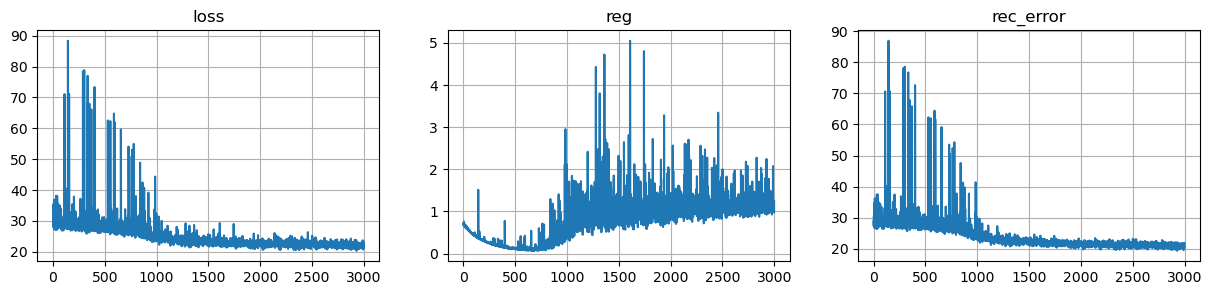

In [19]:
fig, axes = trainer.plot_training_logs(
    keys_to_plot=["loss", "reg", "rec_error"],
    figsize=(15, 3)
)
for ax in axes:
    ax.grid(True)
fig.show()

## Posterior Predictive distribution.

### Sample posterior predictive.

In [20]:
sample_post_predictive = True
if sample_post_predictive:
    n_posterior_samples = 150
    n_likelihood_samples = 1

    x = torch.from_numpy(val_data.state_data).float().to(DEVICE)
    condition = {perturbation_covariates:torch.from_numpy(val_data.perturbation_data[perturbation_covariates]).float().to(DEVICE)}

    # encoding conditions
    if vae.is_conditional:
        assert condition is not None
        latent_cond = vae.encode_condition(condition)
    else:
        latent_cond = None
    z_params = vae.get_latent_params(x, latent_condition=latent_cond)
    z_posterior = vae.sample_from_params(n_posterior_samples, z_params) # m: (N, B, Z)

    if latent_cond is not None:
        latent_cond = latent_cond.unsqueeze(0).repeat(n_posterior_samples, *(1 for _ in latent_cond.shape))
    x_params = vae.get_decoded_params(z_posterior, latent_condition=latent_cond)
    x_samples = vae.sample_from_params(n_likelihood_samples, x_params).detach().cpu().numpy()
    posterior_predicting_dict = {
        "z_params": z_params,
        "z_samples": z_posterior,
        "x_params": x_params,
        "x_samples": x_samples,
        "latent_cond": latent_cond
    }

### Visualizing posterior params.

Text(0.5, 1.0, 'Variance of posterior')

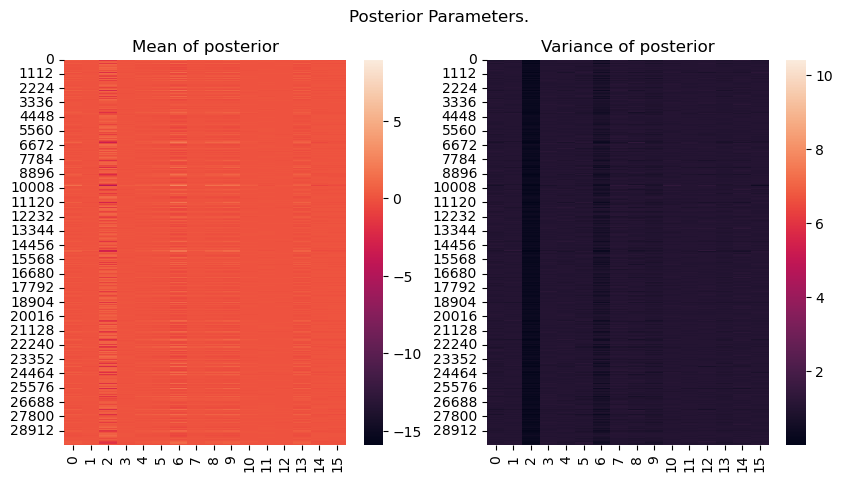

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Posterior Parameters.")
sns.heatmap(posterior_predicting_dict["z_params"][ParamsFields.MEAN].detach().cpu().numpy(), ax=ax[0])
sns.heatmap(np.exp(2*posterior_predicting_dict["z_params"][ParamsFields.COVARIANCE].detach().cpu().numpy()), ax=ax[1])
ax[0].set_title("Mean of posterior")
ax[1].set_title("Variance of posterior")

### Visualizing likelihood parameters.

Text(0.5, 1.0, 'Variance of likelihood')

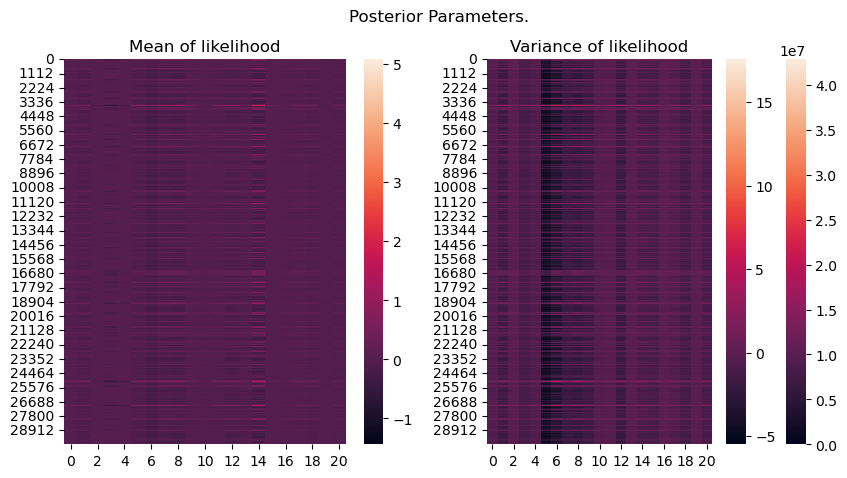

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Posterior Parameters.")
sns.heatmap(posterior_predicting_dict["x_params"][ParamsFields.MEAN].mean(0).detach().cpu().numpy(), ax=ax[0])
sns.heatmap(np.exp(2*posterior_predicting_dict["x_params"][ParamsFields.COVARIANCE].mean(0).detach().cpu().numpy()), ax=ax[1])
sns.heatmap(2*posterior_predicting_dict["x_params"][ParamsFields.COVARIANCE].mean(0).detach().cpu().numpy(), ax=ax[1])
ax[0].set_title("Mean of likelihood")
ax[1].set_title("Variance of likelihood")

### Plotting samples

(87, 21)


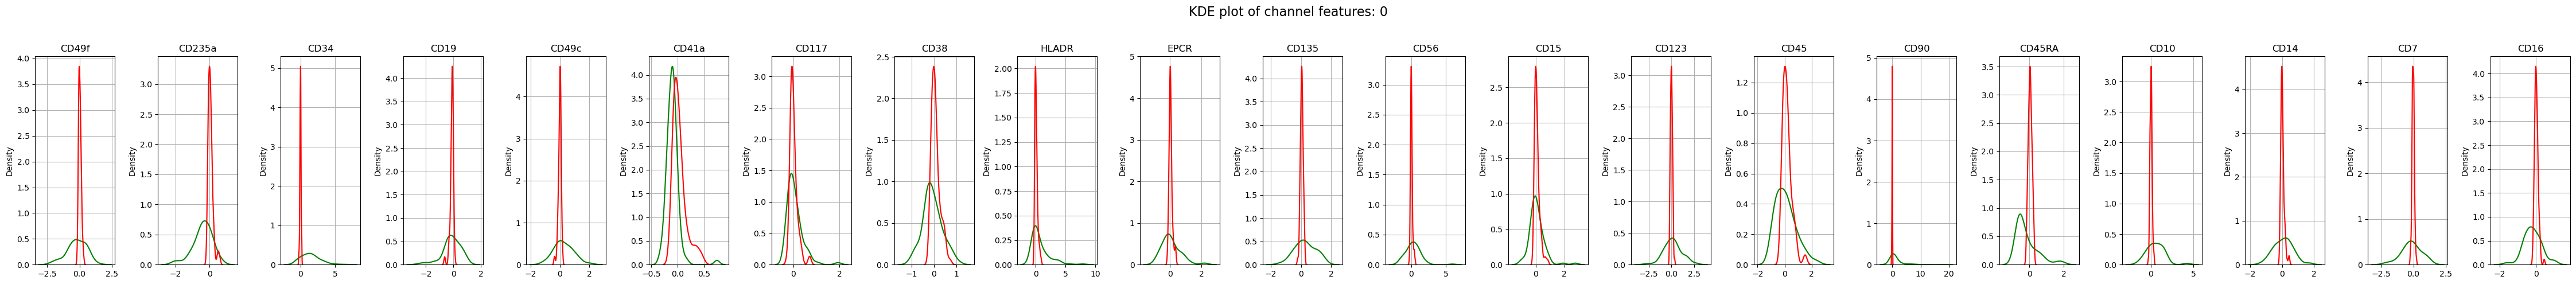

(166, 21)


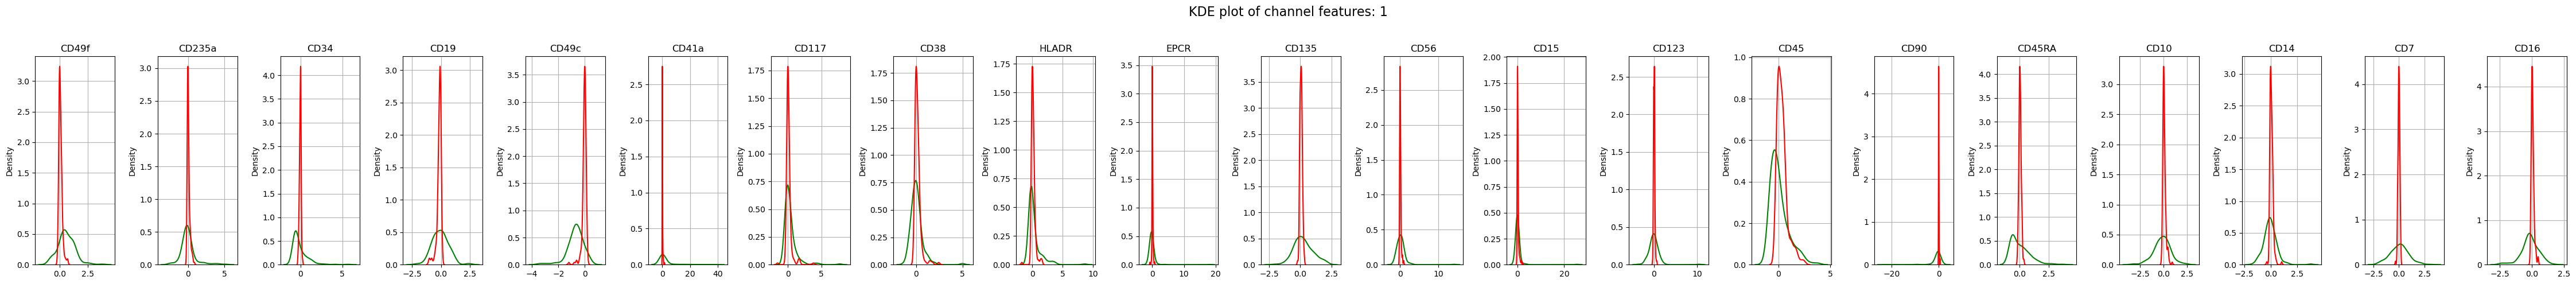

(29, 21)


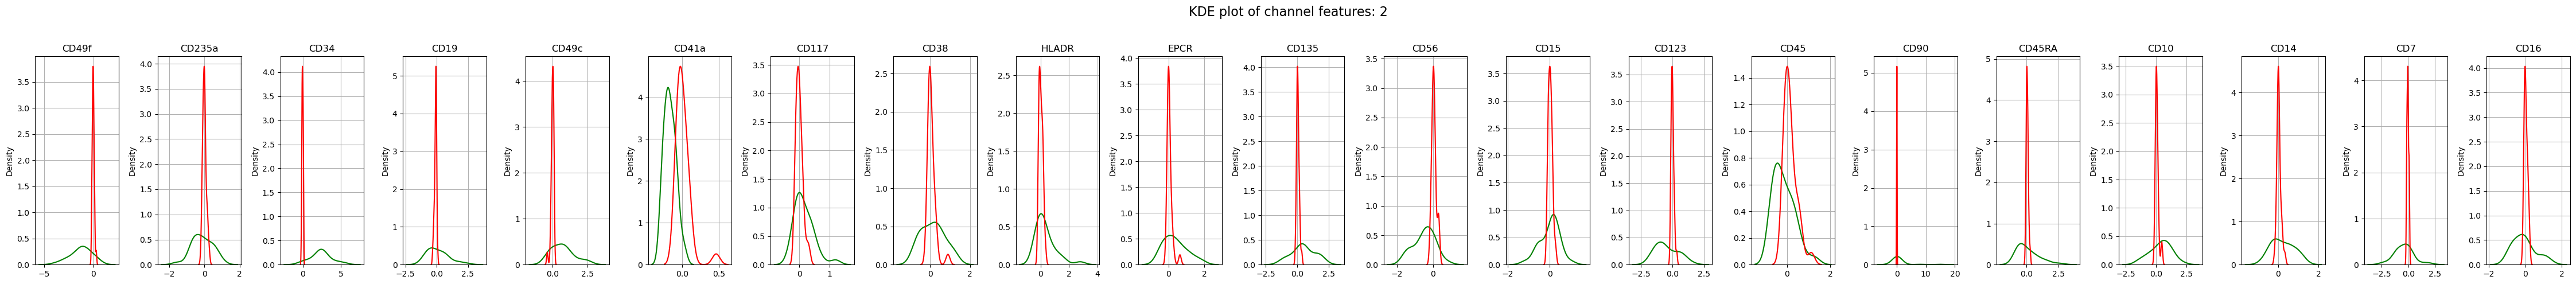

(137, 21)


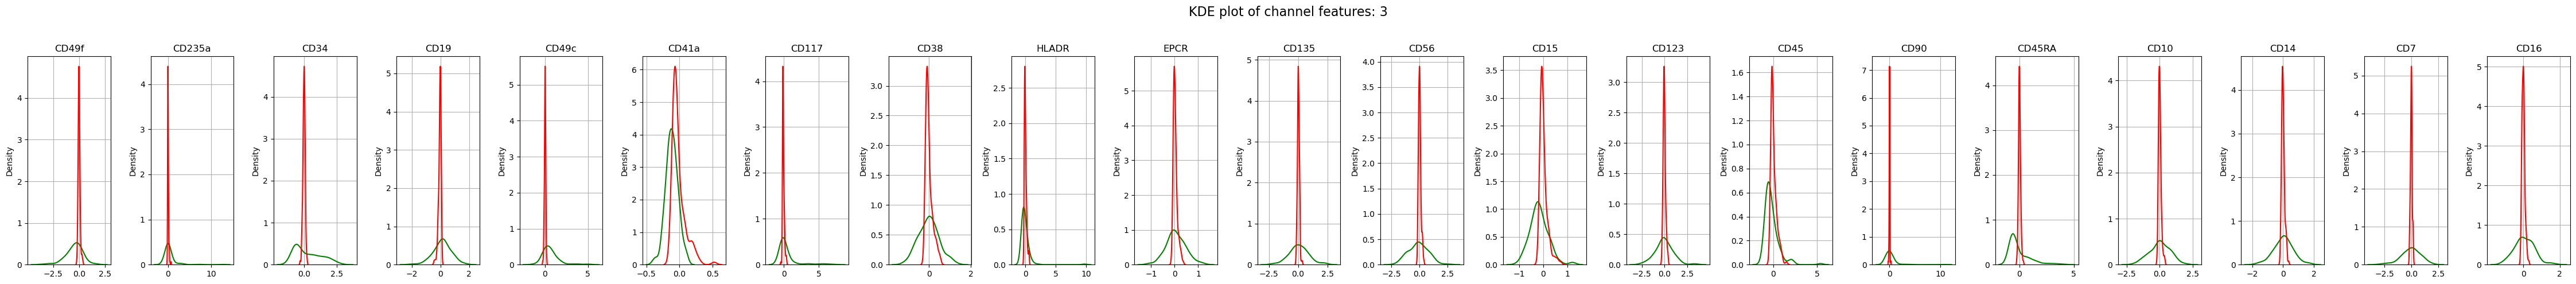

(52, 21)


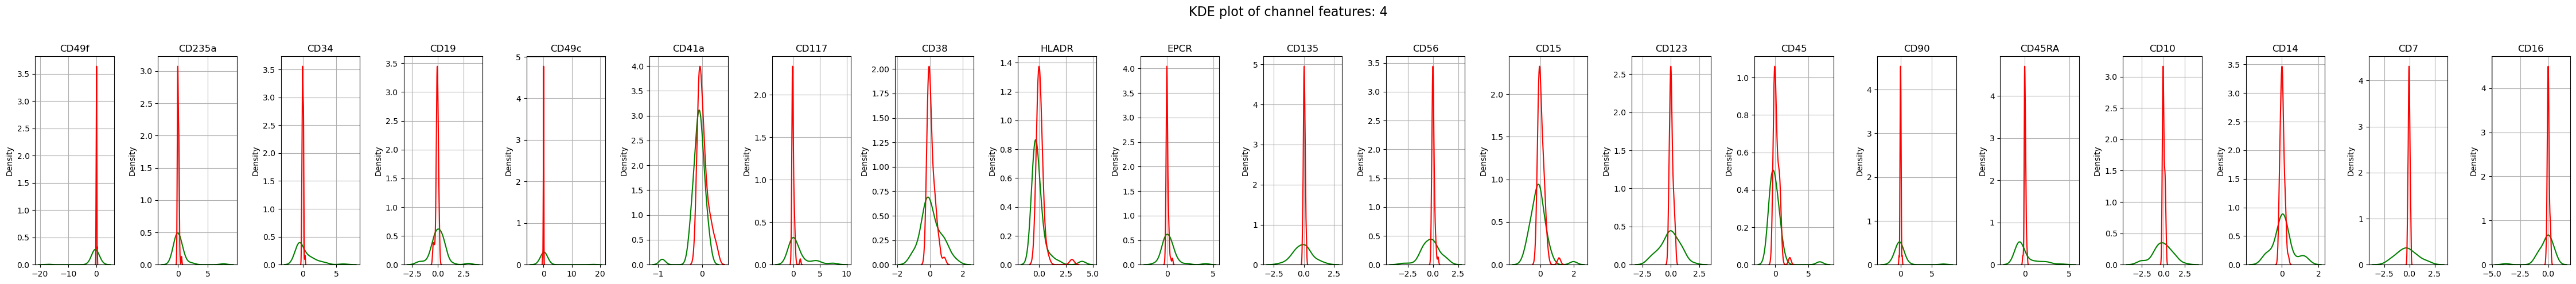

(9, 21)


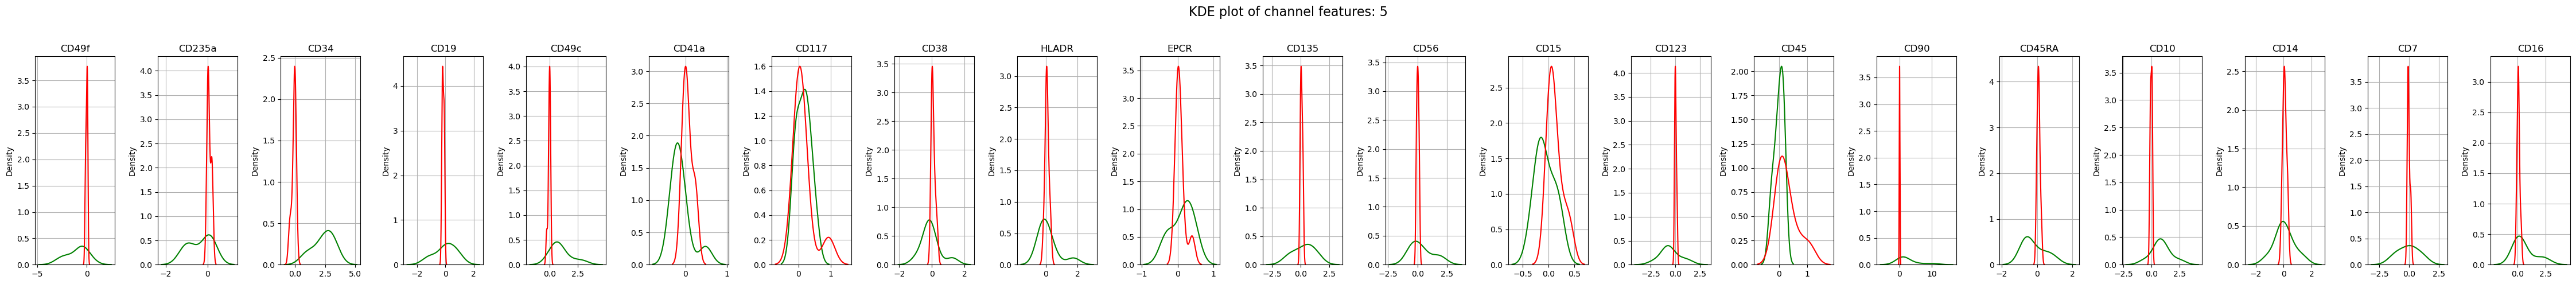

(20, 21)


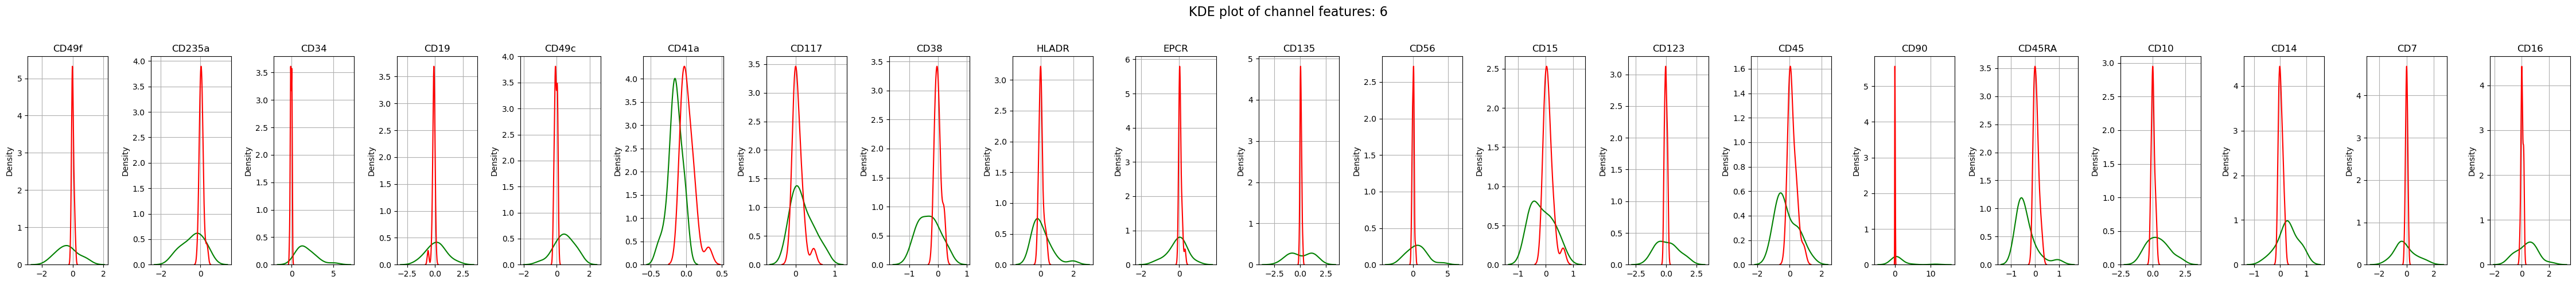

(10, 21)


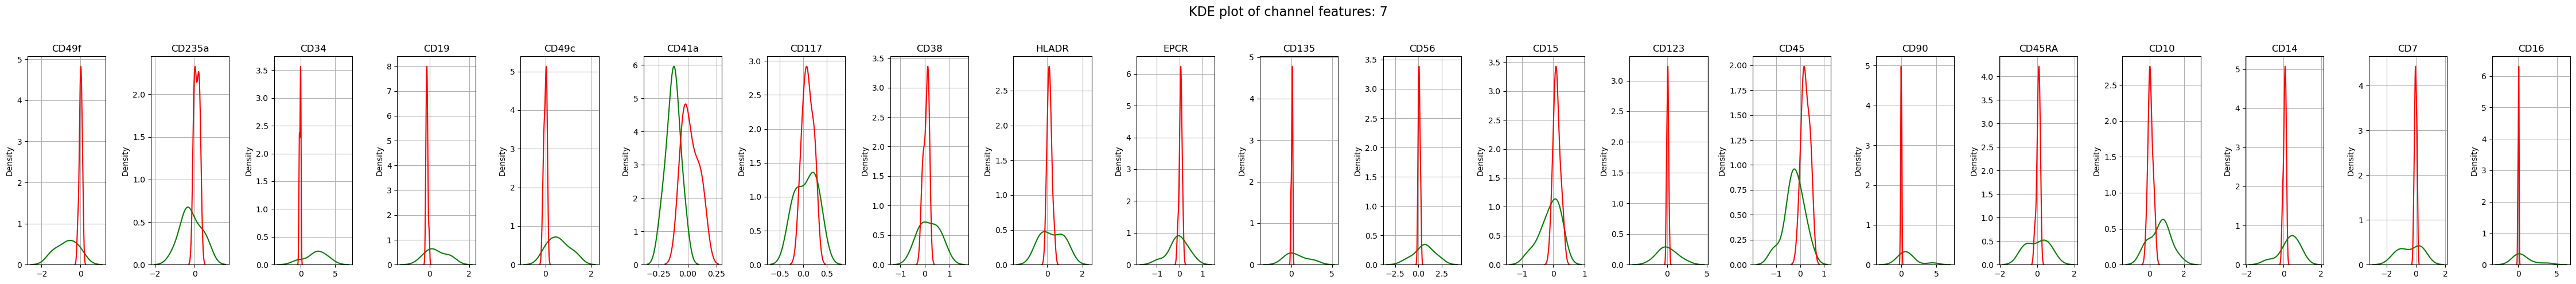

(12, 21)


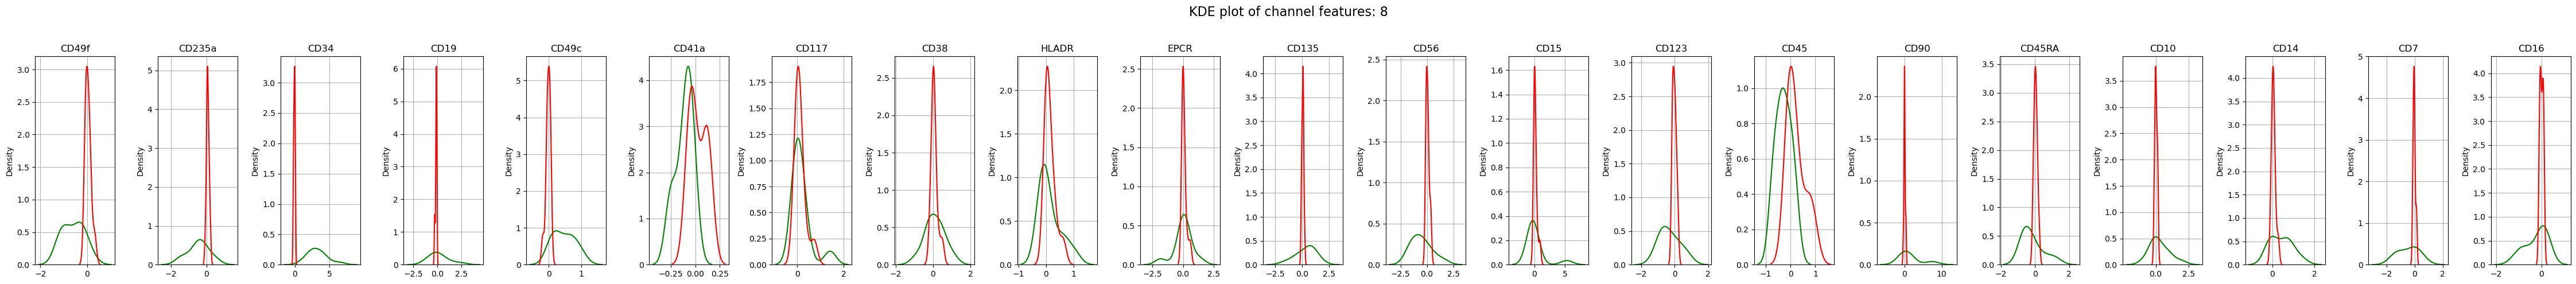

(69, 21)


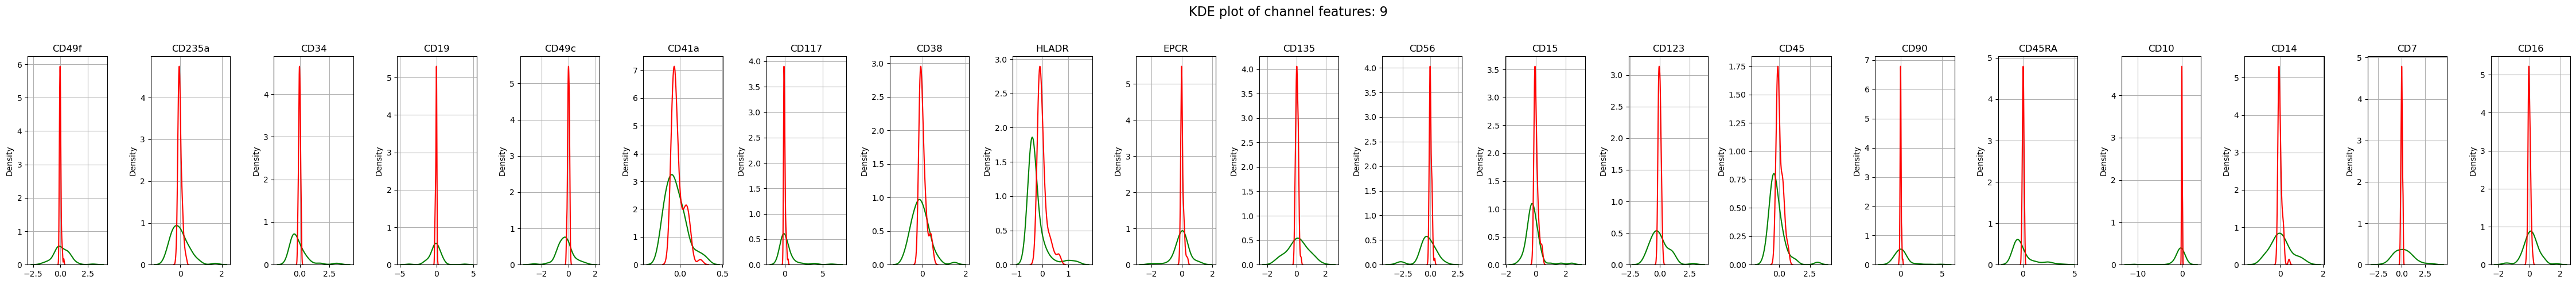

(75, 21)


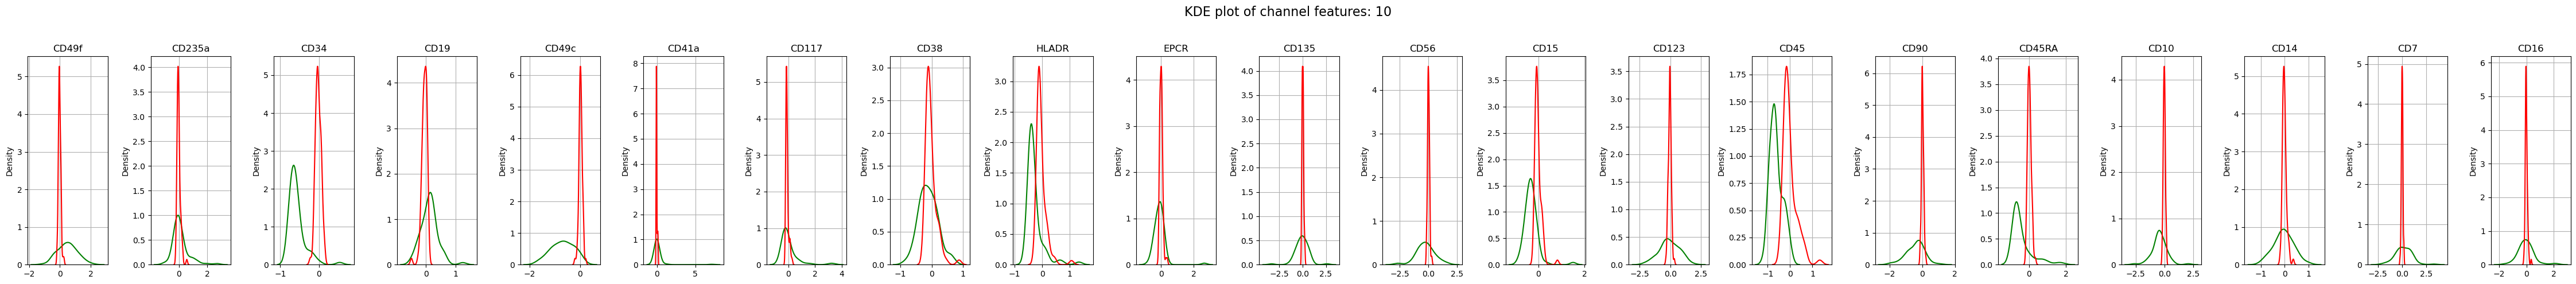

(55, 21)


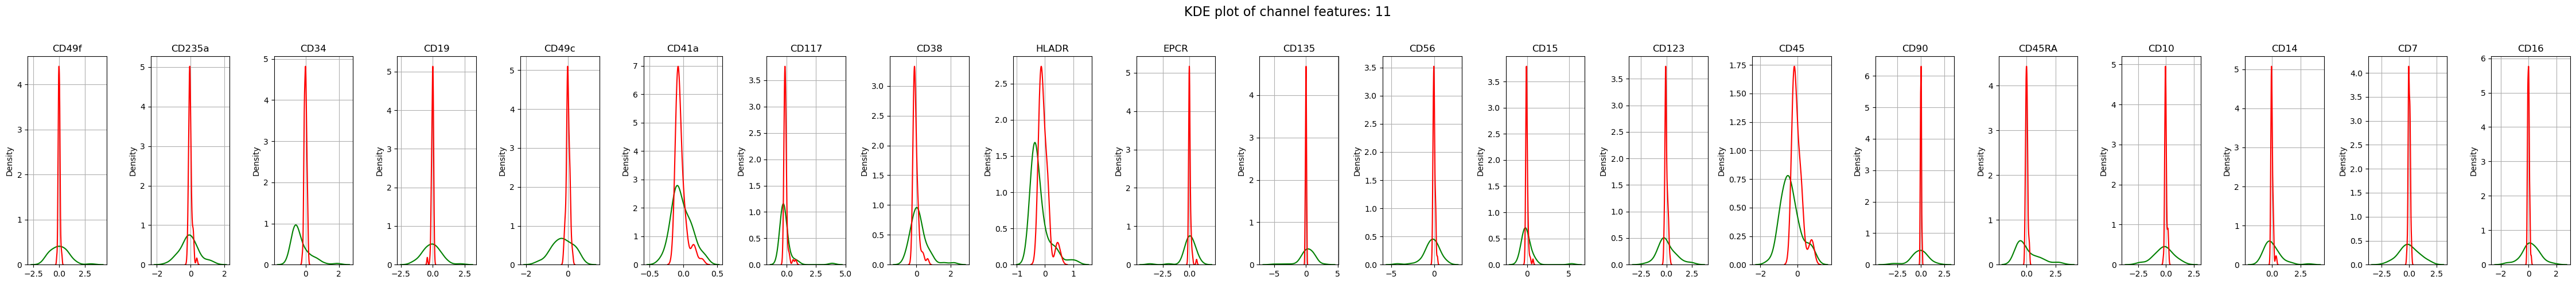

(58, 21)


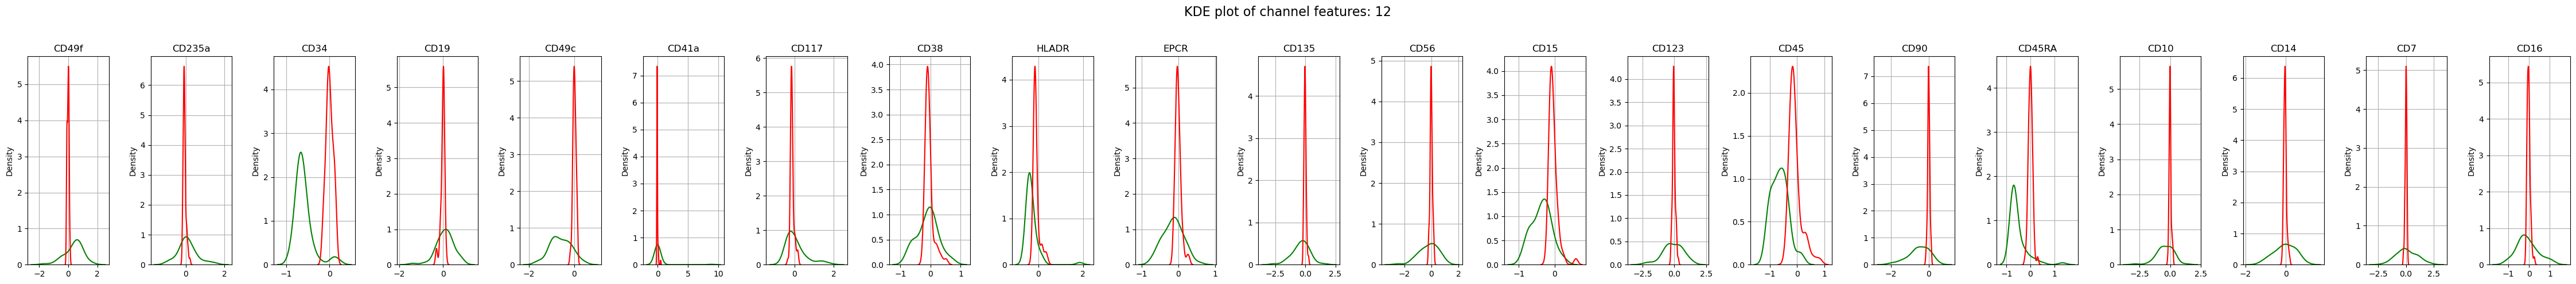

(40, 21)


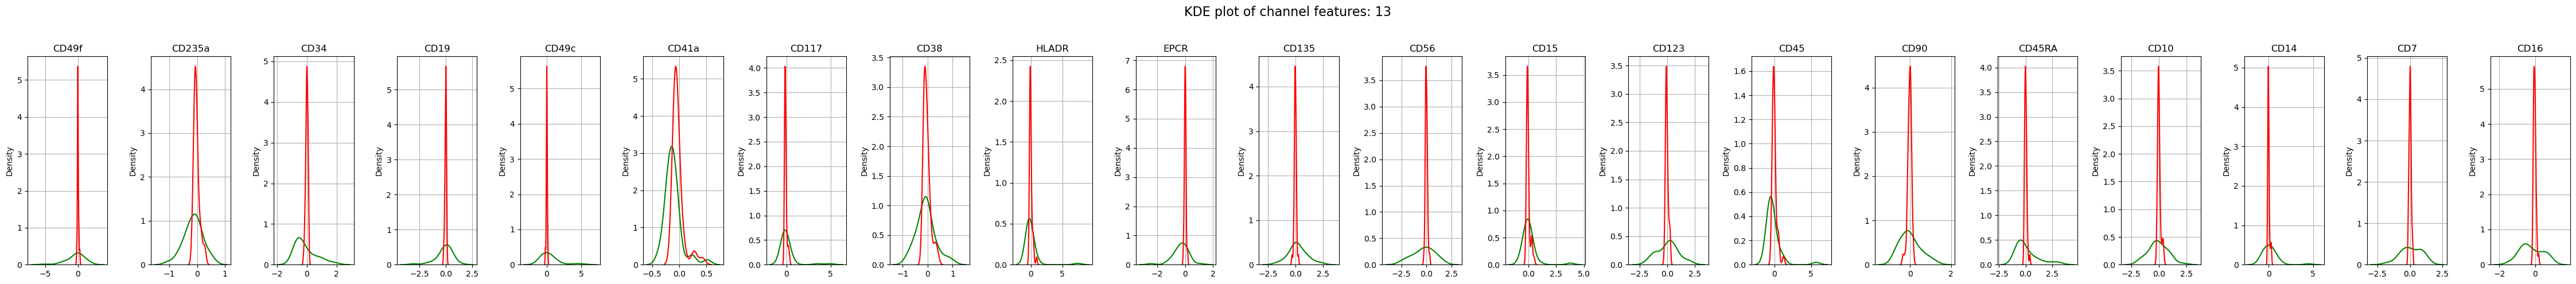

(59, 21)


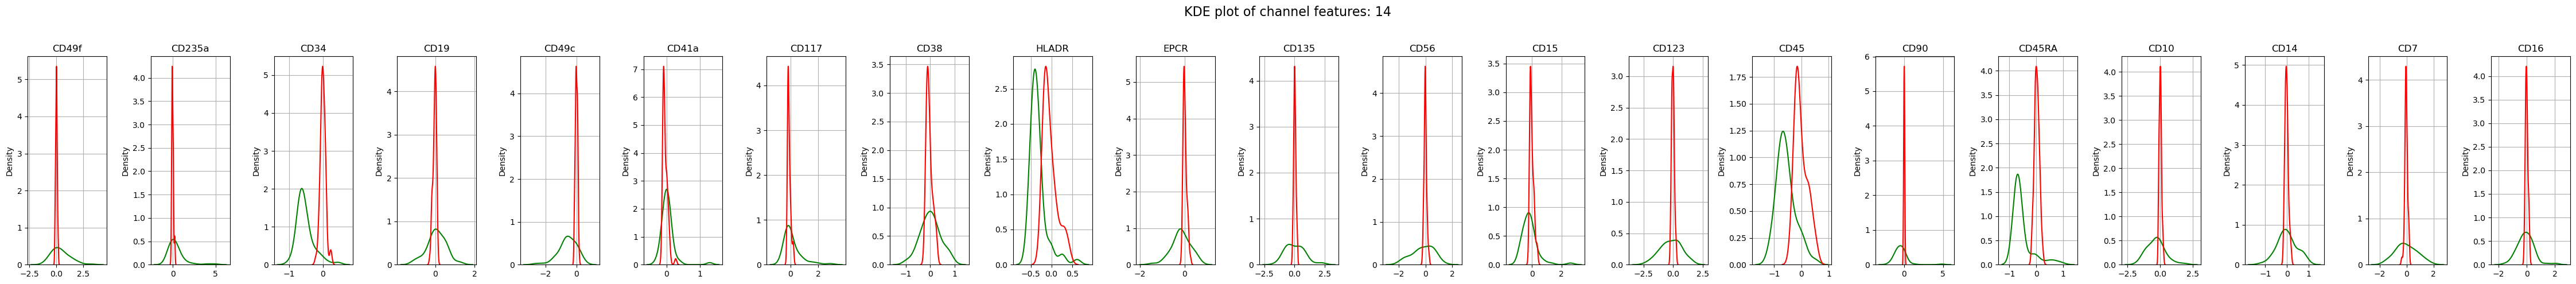

In [ ]:
# make sure adata.obs['cel\l_type'] exists
n_channels = adata.shape[1]
perturbation_repr = train_data.data.perturbation_covariates[0]
X_validation = val_data.state_data
E_validation = val_data.perturbation_data[perturbation_repr]
num_samples_per_protocol = 200
unique_protocols = np.unique(E_validation, axis=0)

for protocol_idx, protocol_data in enumerate(unique_protocols):
    idx_cells = (E_validation == protocol_data).all(-1)
    X_subset = val_data.state_data[idx_cells, :]
    X_subset = val_data.state_data[idx_cells, :]
    X_gen = x_samples[0, :, idx_cells, :].mean(1)
    print(X_gen.shape)
    fig, ax = plt.subplots(1, n_channels, figsize=(45, 5))
    fig.suptitle(f"KDE plot of channel features: {protocol_idx}", fontsize=16)
    for i in range(n_channels):
        sns.kdeplot(X_subset[:, i], ax=ax[i], color="green", label="Real")
        sns.kdeplot(X_gen[:, i], ax=ax[i], color="red", label="Generated")
        ax[i].grid(True)
        ax[i].set_title(adata.var_names[i])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## Prior Predictive Distribution.

### Sampling prior predictive distribution.

In [ ]:
sample_prior_predictive = True
if sample_prior_predictive:
    n_prior_samples = 50
    n_likelihood_samples = 1000

    unique_protocols = np.unique(val_data.perturbation_data[perturbation_covariates], axis=0)
    condition = {perturbation_covariates:torch.from_numpy(unique_protocols).float().to(DEVICE)}
    
    # encoding conditions
    if vae.is_conditional:
        assert condition is not None
        latent_cond = vae.encode_condition(condition)
        latent_cond = latent_cond.unsqueeze(0).repeat(n_prior_samples, *(1 for _ in latent_cond.shape))
    else:
        latent_cond = None
    z_prior = torch.randn((n_prior_samples, unique_protocols.shape[0], vae.state_latent_dim)).float().to(DEVICE)
    x_params = vae.get_decoded_params(z_prior, latent_condition=latent_cond)
    x_samples = vae.sample_from_params(n_likelihood_samples, x_params).detach().cpu().numpy()
    prior_predicting_dict = {
        "z_params": z_params,
        "z_samples": z_posterior,
        "x_params": x_params,
        "x_samples": x_samples,
        "latent_cond": latent_cond
    }

### Visualizing likelihood parameters.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Posterior Parameters.")
sns.heatmap(prior_predicting_dict["x_params"][ParamsFields.MEAN].mean(0).detach().cpu().numpy(), ax=ax[0])
sns.heatmap(np.exp(2*prior_predicting_dict["x_params"][ParamsFields.COVARIANCE].mean(0).detach().cpu().numpy()), ax=ax[1])
sns.heatmap(2*prior_predicting_dict["x_params"][ParamsFields.COVARIANCE].mean(0).detach().cpu().numpy(), ax=ax[1])
ax[0].set_title("Mean of likelihood")
ax[1].set_title("Variance of likelihood")

### Plotting samples.

In [ ]:
for protocol_idx, protocol_data in enumerate(unique_protocols):
    idx_cells = (E_validation == protocol_data).all(-1)
    X_subset = val_data.state_data[idx_cells, :]
    X_subset = val_data.state_data[idx_cells, :]
    X_gen = x_samples[:, :, protocol_idx, :].mean(1)
    print(X_gen.shape)
    fig, ax = plt.subplots(1, n_channels, figsize=(45, 5))
    fig.suptitle(f"KDE plot of channel features: {protocol_idx}", fontsize=16)
    for i in range(n_channels):
        sns.kdeplot(X_subset[:, i], ax=ax[i], color="green", label="Real")
        sns.kdeplot(X_gen[:, i], ax=ax[i], color="red", label="Generated")
        ax[i].grid(True)
        ax[i].set_title(adata.var_names[i])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()